<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Детекция объектов</b></h3>

В этом домашнем задании мы продолжим работу над детектором из семинара, поэтому при необходимости можете заимствовать оттуда любой код.

Домашнее задание можно разделить на следующие части:

* Переделываем модель [4]
  * Backbone[1],
  * Neck [2],
  * Head [1]
* Label assignment [3]:
  * TAL [3]
* Лоссы [1]:
  * CIoU loss [1]
* Кто больше? [5]
  * 0.05 mAP [1]
  * 0.1 mAP  [2]
  * 0.2 mAP [5]

**Максимальный балл:** 10 баллов. (+3 балла бонус).

In [1]:
!pip install torchmetrics -q

In [2]:
import os
import math
from functools import partial
from collections import Counter, defaultdict

import io
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.ops import nms, box_iou, sigmoid_focal_loss
from torchvision.models.detection.anchor_utils import AnchorGenerator

from torchmetrics.detection import MeanAveragePrecision

In [3]:
import torch
import numpy as np
import pandas as pd
import albumentations as A

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from albumentations.pytorch.transforms import ToTensorV2

### Загрузка данных

Мы продолжаем работу с датасетом из семинара - Halo infinite ([сслыка](https://universe.roboflow.com/graham-doerksen/halo-infinite-angel-aim)). Загрузка данных и создание датасета полностью скопированы из семинара.

Сначала загружаем данные

In [4]:
class_to_color = {
    1: (89, 161, 197), # голубой цвет
    2: (204, 79, 135), # розовый
    3: (125, 216, 93), # зеленый
    4: (175, 203, 33), # желто-зеленый
}

class_to_name = {
    1 : "enemy",
    2 : "enemy-head",
    3 : "friendly",
    4 : "friendly-head"
}

splits = {'train': 'data/train-00000-of-00001-0d6632d599c29801.parquet',
          'validation': 'data/validation-00000-of-00001-c6b77a557eeedd52.parquet',
          'test': 'data/test-00000-of-00001-866d29d8989ea915.parquet'}
df_train = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["train"])
df_val = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["validation"])
df_test = pd.read_parquet("hf://datasets/Francesco/halo-infinite-angel-videogame/" + splits["test"])

Выведем пример данных

In [5]:
df_train.head()

,image_id,image,width,height,objects
0,311,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,640,640,"{'id': [573, 574], 'area': [1748, 15756], 'bbo..."
1,67,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,640,640,"{'id': [137, 138], 'area': [14136, 88392], 'bb..."
2,161,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,640,640,"{'id': [301, 302], 'area': [3016, 33768], 'bbo..."
3,210,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,640,640,"{'id': [379, 380], 'area': [832, 9248], 'bbox'..."
4,142,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,640,640,"{'id': [272, 273], 'area': [1520, 16704], 'bbo..."


In [6]:
# Вспомогательные функции для отрисовки данных
def add_bbox(image, box, label='', color=(128, 128, 128), txt_color=(0, 0, 0)):
    lw = max(round(sum(image.shape) / 2 * 0.003), 2)
    p1, p2 = (int(box[0]), int(box[1])), (int(box[0]) + int(box[2]), int(box[1]) + int(box[3]))
    cv2.rectangle(image, p1, p2, color, thickness=lw, lineType=cv2.LINE_AA)
    if label:
        tf = max(lw - 1, 1)
        w, h = cv2.getTextSize(label, 0, fontScale=lw / 3, thickness=tf)[0]
        outside = p1[1] - h >= 3
        p2 = p1[0] + w, p1[1] - h - 3 if outside else p1[1] + h + 3
        cv2.rectangle(image, p1, p2, color, -1, cv2.LINE_AA)
        cv2.putText(image,
                    label, (p1[0], p1[1] - 2 if outside else p1[1] + h + 2),
                    0,
                    lw / 3,
                    txt_color,
                    thickness=tf,
                    lineType=cv2.LINE_AA)
    return image

def plot_examples(df, indices=None, num_examples=6, row_figsize=(12, 3)):
    if indices is None:
        indices = np.random.choice(len(df), size=num_examples, replace=False)
    else:
        num_examples = len(indices)
    ncols = min(num_examples, 3)
    nrows = math.ceil(num_examples / 3)
    _, axes = plt.subplots(nrows, ncols, figsize=(row_figsize[0], row_figsize[1] * nrows), tight_layout=True)
    axes = axes.reshape(-1)
    for ix, ax in zip(indices, axes):
        row = df.iloc[ix]
        image = Image.open(io.BytesIO(row['image']['bytes']))
        bboxes = row["objects"]['bbox']
        classes = row["objects"]['category']
        img = np.array(image)
        for bbox, label in zip(bboxes, classes):
            color = class_to_color[label]
            class_name = class_to_name[label]
            img = add_bbox(img, bbox, label=str(class_name), color=color)
        ax.imshow(img)
        ax.set_title(f"Image id: {row['image_id']}")
        ax.set_xticks([])
        ax.set_yticks([])


Нарисуем несколько примеров картинок из обучающей выборки

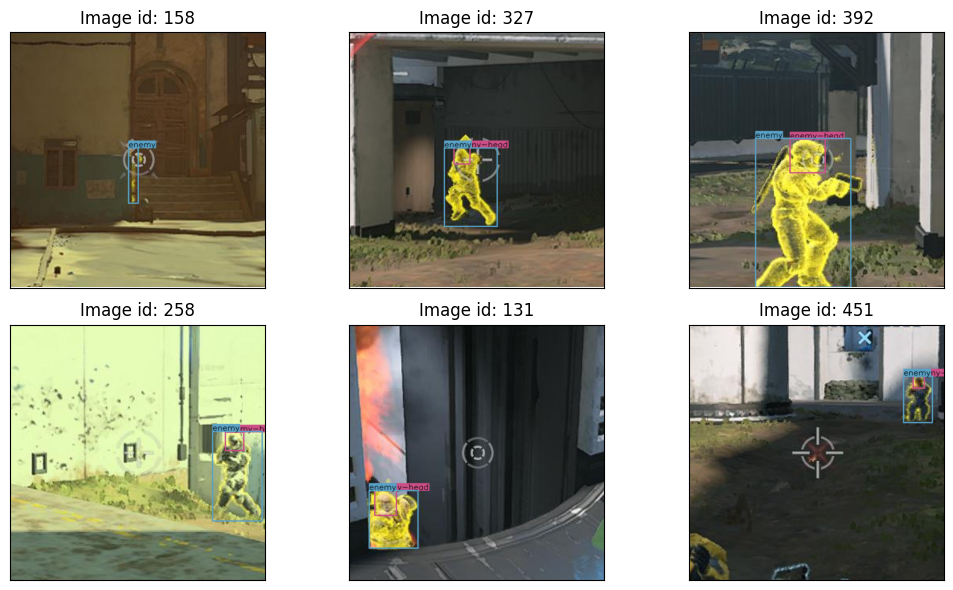

In [7]:
plot_examples(df_train)

Посчитаем количество данных в двух датасетах

In [8]:
print(f"Train: {len(df_train)}")
print(f"Validation: {len(df_val)}")
print(f"Test: {len(df_test)}")

Train: 462
Validation: 71
Test: 136


Посмотрим на некоторые статистики по датасету

Min bboxes per image: 0
Max bboxes per image: 6
Mean bboxes per image: 1.84


Number of object per class:
enemy-head : 331
enemy : 387
friendly-head : 37
friendly : 93

Mean bbox size per class:
enemy : [117.48837 205.58656]
enemy-head : [46.95468  49.123867]
friendly : [113.91398 213.46237]
friendly-head : [61.45946 57.62162]





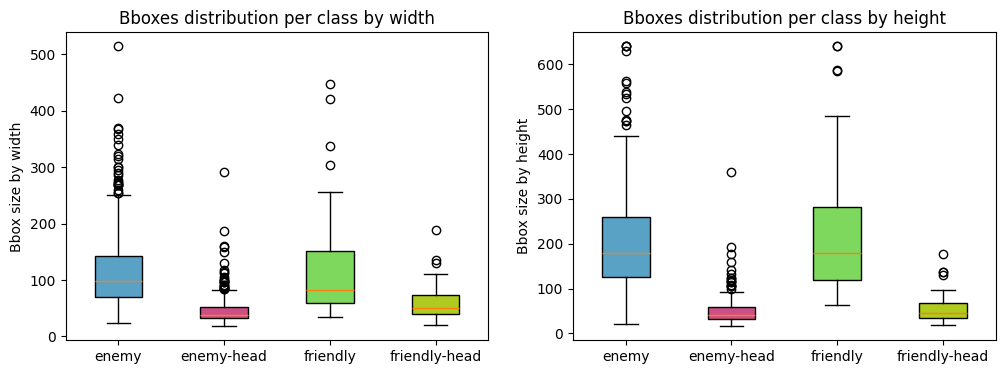

In [9]:
def part_info(df):
    """ Считаем статистики по датасету и рисуем распределение размеров ббоксов по классам. """
    df = pd.json_normalize(df['objects'])[["bbox", "category"]]
    obj_per_img = df['bbox'].apply(lambda obj: len(obj))
    print(f"Min bboxes per image: {obj_per_img.min()}")
    print(f"Max bboxes per image: {obj_per_img.max()}")
    print(f"Mean bboxes per image: {obj_per_img.mean():.3}")

    all_categories = df['category'].apply(lambda obj: obj).tolist()
    counter = Counter(np.concatenate(all_categories))
    msg = [f"{class_to_name[key]} : {value}" for key, value in counter.items()]
    print("\n\nNumber of object per class:\n" + "\n".join(msg))

    bboxes = defaultdict(list)
    for _, row in df.iterrows():
        for bb, cls in zip(row['bbox'], row['category']):
            bboxes[cls].append(list(bb[2:]))
    bboxes = dict(sorted(bboxes.items()))
    print("\nMean bbox size per class:")
    for cls, boxes_list in bboxes.items():
        print(f"{class_to_name[cls]} : {np.mean(boxes_list, axis=0)}")

    print("\n\n")
    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    x_boxes = [np.array(val)[:, 0] for val in bboxes.values()]
    y_boxes = [np.array(val)[:, 1] for val in bboxes.values()]
    labels = [class_to_name[cls] for cls in class_to_name.keys()]
    colors = [class_to_color[cls] for cls in class_to_color.keys()]
    for ax, box, direction in zip(axes, [x_boxes, y_boxes], ["width", "height"]):
        bplot = ax.boxplot(box, patch_artist=True, tick_labels=labels)
        for patch, color in zip(bplot["boxes"], colors):
            patch.set_facecolor(np.array(color) / 255)
        ax.set_ylabel(f"Bbox size by {direction}")
        ax.set_title(f"Bboxes distribution per class by {direction}")

box_sizes = part_info(df_train)

Видим сильный дисбаланс классов. `Friendly-head` и `Friendly` сильно меньше чем остальные два класса. <br>


| Класс | ID | Ширина (px) | Высота (px) | Размер | Форма |
|-------|-----|-------------|-------------|--------|-------|
| **enemy-head** | 2 | ~47 | ~49 | Маленькие | Почти квадратные |
| **friendly-head** | 4 | ~61 | ~58 | Средние | Почти квадратные |
| **enemy** | 1 | ~117 | ~206 | Большие | Сильно вытянутые |
| **friendly** | 3 | ~114 | ~213 | Большие | Сильно вытянутые |



Min bboxes per image: 0
Max bboxes per image: 6
Mean bboxes per image: 1.9


Number of object per class:
enemy-head : 104
enemy : 113
friendly-head : 12
friendly : 30

Mean bbox size per class:
enemy : [114.0531 207.9469]
enemy-head : [44.057693 46.384617]
friendly : [ 99.8     215.26666]
friendly-head : [44.       39.166668]





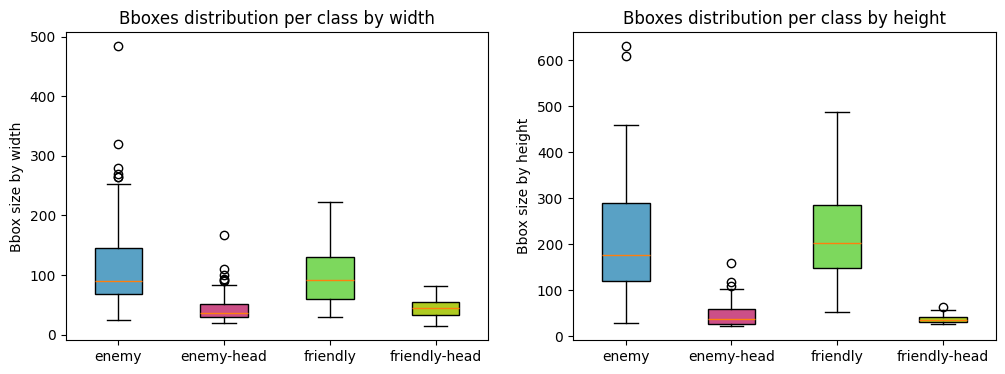

In [10]:
box_sizes = part_info(df_test)


Объектов на изображение:
  0 объектов: 87 изображений
  1-2 объекта: 296
  3+ объектов: 79

Площади объектов (пиксели):
  min: 320
  max: 288868
  mean: 19148
  median: 6928


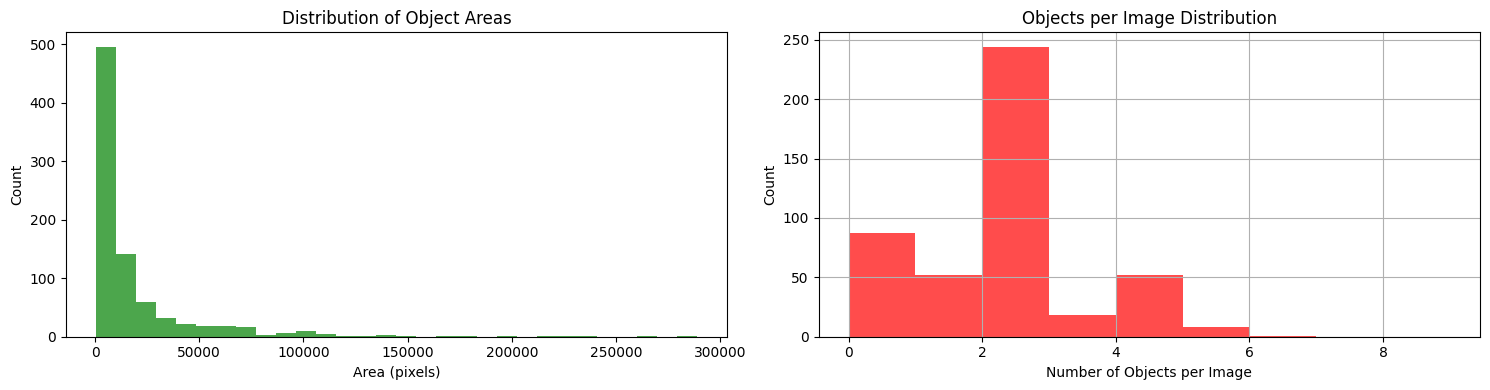

In [11]:
def advanced_dataset_stats(df):
    """Расширенная статистика датасета"""
    df = pd.json_normalize(df['objects'])[["bbox", "category"]]
    
    # Плотность объектов (количество на изображение)
    objects_per_img = df['bbox'].apply(len)
    print(f"\nОбъектов на изображение:")
    print(f"  0 объектов: {(objects_per_img == 0).sum()} изображений")
    print(f"  1-2 объекта: {((objects_per_img > 0) & (objects_per_img <= 2)).sum()}")
    print(f"  3+ объектов: {(objects_per_img >= 3).sum()}")
    
    # Площади объектов
    areas = []
    for _, row in df.iterrows():
        for bb in row['bbox']:
            areas.append(bb[2] * bb[3])
    
    print(f"\nПлощади объектов (пиксели):")
    print(f"  min: {np.min(areas):.0f}")
    print(f"  max: {np.max(areas):.0f}")
    print(f"  mean: {np.mean(areas):.0f}")
    print(f"  median: {np.median(areas):.0f}")
    
    # Визуализация распределения
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    # Гистограмма площадей
    axes[0].hist(areas, bins=30, alpha=0.7, color='green')
    axes[0].set_xlabel('Area (pixels)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of Object Areas')
    
    # Объектов на изображение
    objects_per_img.hist(ax=axes[1], bins=range(0, 10), alpha=0.7, color='red')
    axes[1].set_xlabel('Number of Objects per Image')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Objects per Image Distribution')
    
    plt.tight_layout()
    plt.show()
    
    return areas 

areas = advanced_dataset_stats(df_train)

Преобладают изображения с 1-2 объектами (почти 2/3 датасета) <br>
87 изображений без объектов <br>
Сильный разброс площади объектов - есть небольшое количество очень больших объектов, которые сильно влияют на среднее

Создаем датасет для предобработки данных

In [12]:
class HaloDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.objects = self.dataframe["objects"].values
        self.images = self.dataframe["image"].values
        self.image_ids = self.dataframe["image_id"].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        import io
        import numpy as np
        import torch
        from PIL import Image

        # загрузка и нормализация изображения
        image_bytes = self.images[idx]["bytes"]
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        image = np.array(image).astype(np.float32) / 255.0
        image_id = self.image_ids[idx]

        # извлекаем аннотации
        obj = self.objects[idx]
        boxes_data = obj["bbox"]
        labels_data = obj["category"]

        # обработка меток 
        if isinstance(labels_data, (int, float)):
            labels = [labels_data - 1]
        else:  # numpy array
            labels = [int(l) - 1 for l in labels_data]

        # обработка боксов
        boxes = []
        
        if isinstance(boxes_data, np.ndarray):
            if boxes_data.dtype == object:  # массив боксов
                for box in boxes_data:
                    boxes.append([float(x) for x in box])
            elif boxes_data.ndim == 1:  # один бокс
                boxes.append([float(x) for x in boxes_data])
            else:  # матрица боксов
                for box in boxes_data:
                    boxes.append([float(x) for x in box])

        boxes = np.array(boxes, dtype=np.float32) if boxes else np.zeros((0, 4), dtype=np.float32)

        # xywh -> xyxy
        if len(boxes) > 0:
            boxes_xyxy = boxes.copy()
            boxes_xyxy[:, 2] = boxes[:, 0] + boxes[:, 2]
            boxes_xyxy[:, 3] = boxes[:, 1] + boxes[:, 3]
            boxes = boxes_xyxy

        # применяем аугментацию
        if self.transform is not None:
            transformed = self.transform(
                image=image,
                bboxes=boxes.tolist() if len(boxes) > 0 else [],
                labels=labels
            )
            image = transformed["image"]
            boxes = transformed["bboxes"]
            labels = transformed["labels"]
            
            # заново синхронизируем после аугментации
            if len(boxes) != len(labels):
                min_len = min(len(boxes), len(labels))
                boxes = boxes[:min_len]
                labels = labels[:min_len]
            
            boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.empty((0, 4), dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.empty((0,), dtype=torch.int64)
        else:
            image = transforms.ToTensor()(image)
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        return image, {"image_id": image_id, "boxes": boxes, "labels": labels}

# собираем изображения в один батч
def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    targets = [item[1] for item in batch]
    return images, targets

In [13]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

IMG_SIZE = 320

train_transform = A.Compose(
    [
        A.Resize(IMG_SIZE, IMG_SIZE),# меняем размер
        A.HorizontalFlip(p=0.5), # горизонтально
        A.RandomBrightnessContrast( # разная освещенность
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5,
        ),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15,
                             val_shift_limit=10, p=0.4),
        A.MotionBlur(blur_limit=3, p=0.2),
        A.GaussNoise(p=0.2), # зернистость
        A.Affine(scale=(0.9, 1.1),
                 translate_percent=(0.05, 0.05),
                 rotate=(-5, 5),
                 p=0.5),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    # интерпретация координат рамок
    bbox_params=A.BboxParams(
        format='pascal_voc', # абсолютые пиксельные значения
        label_fields=['labels'],
        min_visibility=0.0,
        min_area=0,
    ),
)

val_transform = A.Compose(
    [
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels'],
        min_visibility=0.0,
        min_area=0,
    ),
)

test_transform = val_transform

Не забываем инициализировать наш датасет

In [14]:
# создаем датасеты
train_dataset = HaloDataset(df_train, transform=train_transform)
val_dataset = HaloDataset(df_val, transform=test_transform)
test_dataset = HaloDataset(df_test, transform=test_transform)

Чтобы модель не переобучалась, можно добавить больше аугментаций, весь список можно посмотреть тут [[ссылка](https://explore.albumentations.ai/)].

Какие можно использовать аугментации?
* Добавить зум `RandomResizedCrop`,
* Сделать цветовые аугментации типа `RandomBrightnessContrast` и/или `HueSaturationValue`,
* Добавить шум `GaussNoise`,
* Вырезать случайные части изображения `CoarseDropout`,
* И любые другие!

Аугментации можно комбинировать посредствам `A.OneOf`, `A.SomeOf` или `A.RandomOrder`.

Хоть аугментации ограничиваются только вашей фантазией, перед обучением советуем посмотреть на результат преобразований и убедиться, что изображение ещё поддается детекции:)

In [15]:
def visualize_augmented_dataset(dataset, num_examples=6, denormalize=True):
    indices = np.random.choice(len(dataset), size=min(num_examples, len(dataset)), replace=False)
    ncols = min(num_examples, 3)
    nrows = max(1, math.ceil(num_examples / 3))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    if num_examples == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, (idx, ax) in enumerate(zip(indices, axes)):
        image_tensor, target = dataset[idx]
        
        # Конвертируем тензор в numpy (C, H, W) -> (H, W, C)
        img = image_tensor.cpu().permute(1, 2, 0).numpy()

        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)
   
        # Если всё ещё чёрное, принудительно нормализуем
        if img.max() - img.min() < 0.01:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        ax.imshow(img)
        
        # Рисуем GT боксы
        for box, label in zip(target['boxes'], target['labels']):
            x1, y1, x2, y2 = box.numpy()
            w, h = x2 - x1, y2 - y1
            
            class_id = int(label) + 1
            color_rgb = class_to_color.get(class_id, (255, 255, 255))
            color_normalized = tuple(c / 255 for c in color_rgb)
            
            rect = plt.Rectangle(
                (x1, y1), w, h,
                fill=False,
                edgecolor=color_normalized,
                linewidth=2
            )
            ax.add_patch(rect)
            
            class_name = class_to_name.get(class_id, f"Class{class_id}")
            ax.text(x1, y1 - 5, class_name, 
                   fontsize=8, color='white',
                   bbox=dict(facecolor=color_normalized, alpha=0.7, pad=1))
        
        ax.set_title(f"Image | {len(target['boxes'])} objects")
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


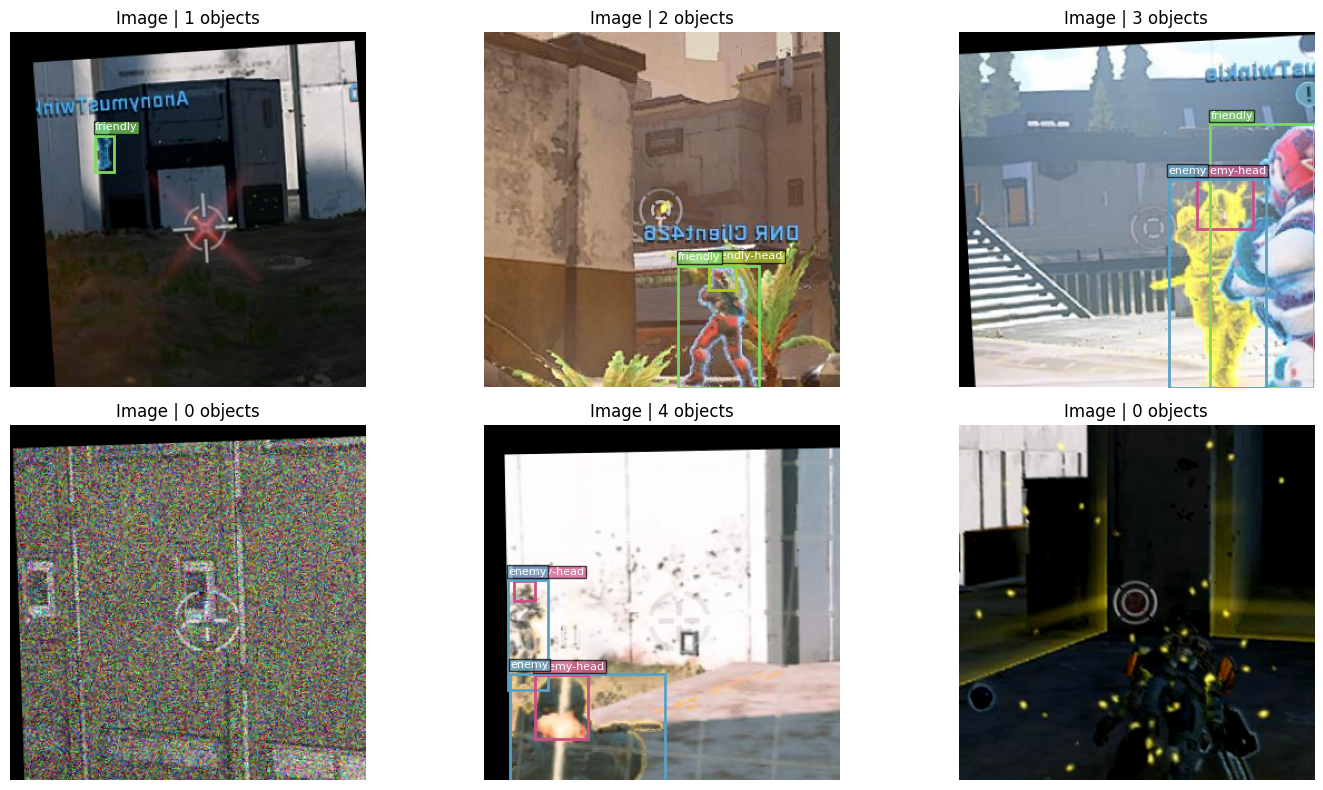

In [16]:
visualize_augmented_dataset(train_dataset, num_examples=6, denormalize=True)

## Переделываем модель [4 балла]

В семинаре мы реализовали самый базовый детектор, а сейчас настало время его улучшать.

### Backbone [1 балл]

Хорошей практикой считается размораживать несколько последних слоев в backbone, это позволяет немного улучить качество модели. Давайте улушчим класс Backbone из лекции, добавив ему возможность разморозки __k__ последних слоев или блоков (на ваш выбор).

In [17]:
class Backbone(nn.Module):
    def __init__(
        self,
        model_name="efficientnet_b0",
        out_indices=(-3, -2, -1), # какие слои выводить
        unfreeze_last=None, 
        dropout=0.2, # регуляризация
    ):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True, # загружаем веса
            features_only=True,
            out_indices=out_indices, # выводим 3 слоя
        )
        for p in self.backbone.parameters():
            p.requires_grad = True
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        features = self.backbone(x)
        features = [self.dropout(f) for f in features]
        return features


### NECK [2 балла]

Следующее улучшение коснется шеи. Предлагаем реализовать знакомую из лекции архитектуру FPN.

#### Feature Pyramid Network

<center><img src="https://user-images.githubusercontent.com/57972646/69858594-b14a6c00-12d5-11ea-8c3e-3c17063110d3.png"/></center>


* [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144)

Она состоит из top-down пути, в котором происходит 2 вещи:
1. Увеличивается пространственная размерность фичей,
2. С помощью скипконнекшеннов, добавляются фичи из backbone модели.

Для увеличения пространственной размерности используется __nearest neighbor upsampling__, а фичи из шеи и бекбоуна суммируются.

__TIPS__:
* Можете использовать базовые классы из лекции,
* Воспользуйтесь AnchorGenerator-ом, чтобы создавать якоря сразу для нескольких выходов,
* Не забудьте использовать nn.ModuleList, если захотите сделать динамическое количество голов у модели,
* Также, можно добавить доп конволюцию (3х3 с паддингом) у каждого выхода шеи.

In [18]:
# разделяем канал на 2 части
# одну часть обрабатывает bottleneck
# вторую напрямую
# объединяем в конце
class CSPBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        hidden = channels // 2

        self.conv1 = nn.Sequential(
            nn.Conv2d(channels, hidden, 1),
            nn.BatchNorm2d(hidden),
            nn.SiLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(channels, hidden, 1),
            nn.BatchNorm2d(hidden),
            nn.SiLU()
        )
        self.bottleneck = nn.Sequential(
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.SiLU(),
            nn.Conv2d(hidden, hidden, 3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.SiLU(),
        )
        self.merge = nn.Sequential(
            nn.Conv2d(hidden * 2, channels, 1),
            nn.BatchNorm2d(channels),
            nn.SiLU()
        )
        
    def forward(self, x):
        return self.merge(torch.cat([self.bottleneck(self.conv1(x)), self.conv2(x)], dim=1))

# реализация улучшенной версии fpn
class Neck(nn.Module):
    def __init__(self, in_channels_list=(40, 112, 320), out_channels=128):
        super().__init__()
        # 1x1 conv для приведения каналов
        self.lateral = nn.ModuleList([
            nn.Conv2d(in_ch, out_channels, 1) for in_ch in in_channels_list
        ])
        # финальные CSP блоки
        self.output = nn.ModuleList([
            CSPBlock(out_channels) for _ in in_channels_list
        ])

    def forward(self, features):
        c3, c4, c5 = features
        # Top-down путь
        p5 = self.lateral[2](c5)
        p4 = self.lateral[1](c4) + F.interpolate(p5, size=c4.shape[-2:], mode="nearest")
        p3 = self.lateral[0](c3) + F.interpolate(p4, size=c3.shape[-2:], mode="nearest")
        # финальные свертки
        return [self.output[i](p) for i, p in enumerate([p3, p4, p5])]



### Head [1 балл]

В качестве шеи можно выбрать __один из двух__ вариантов:

#### 1. Decoupled Head

Реализовать Decoupled Head из [YOLOX](https://arxiv.org/abs/2107.08430).
<center><img src="https://i.ibb.co/BVtBR2R3/Decoupled-head.jpg"/></center>

**TIP**: Возьмите за основу голову из семинара, тк она сильно похожа на Decoupled Head.

Изменять количество параметров у шей на разных уровнях не обязательно.

#### 2. Confidence score free head

Нужно взять за основу голову из семинара и полностью убрать предсказание confidence score. Чтобы модель предсказывала только 2 группы: ббоксы и классы.

Есть следующие способы удаления confidence score:
* Добавление нового класса ФОН. Обычно его обозначают нулевым классом.
* Присваивание ббоксам БЕЗ объекта вектор из нулей в качестве таргета.

Выберете тот, который вам больше нравится и будте внимательны при расчете лосса!

**Важно!** Удаление confidence score повлияет на следующие методы из семинара:
* target_assign
* ComputeLoss
* _filter_predictions

In [19]:
# финальная предсказывающая часть детектора
class Head(nn.Module):

    def __init__(self, in_channels, num_anchors, num_classes, hidden_channels=256):
        super().__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        self.stem = nn.Conv2d(
            in_channels,
            hidden_channels,
            kernel_size=1
        )
        # ветка классификации
        self.cls_branch = nn.Sequential(
            CSPBlock(hidden_channels),
            CSPBlock(hidden_channels),
            nn.Conv2d(
                hidden_channels,
                num_anchors * num_classes,
                kernel_size=1
            )
        )
        # ветка регрессии
        self.reg_branch = nn.Sequential(
            CSPBlock(hidden_channels),
            CSPBlock(hidden_channels),
            nn.Conv2d(
                hidden_channels,
                num_anchors * (4 + 1),
                kernel_size=1
            )
        )
        # инициализация смещения
        nn.init.constant_(self.reg_branch[-1].bias, -4.5)
        nn.init.constant_(self.cls_branch[-1].bias, -4.5)

    def forward(self, x):
        x = self.stem(x)
        cls_logits = self.cls_branch(x)
        reg_out = self.reg_branch(x)
        bbox_preds = reg_out[:, :self.num_anchors * 4, :, :] # первые 4*num_anchors каналов
        obj_logits = reg_out[:, self.num_anchors * 4:, :, :] # последние num_anchors каналов
        return bbox_preds, obj_logits, cls_logits

Теперь можно снова реализовать класс детектора с учетом всех частей выше!

In [20]:
class Detector(nn.Module):
    def __init__(
        self,
        backbone_model_name="efficientnet_b0",
        neck_out_channels=256,
        num_classes=4,
        anchor_sizes=((12, 20, 32), (40, 60, 90), (110, 160, 220)), # размеры якорей 
        anchor_ratios=((0.7, 1.0, 1.4), (0.7, 1.0, 1.4), (0.7, 1.0, 1.4)), # пропорции
        input_size=(320, 320),
        unfreeze_last=None, 
    ):
        super().__init__()
        self.num_classes = num_classes
        self.input_size = input_size
        self.backbone = Backbone(
            model_name=backbone_model_name,
            out_indices=(-3, -2, -1),
            unfreeze_last=unfreeze_last,
        )
        # получение информации о каналах
        backbone_channels = self.backbone.backbone.feature_info.channels()
        reductions = self.backbone.backbone.feature_info.reduction()
        self.strides = [int(r) for r in reductions]
        self.num_levels = len(self.strides)
        self.neck = Neck(
            in_channels_list=backbone_channels,
            out_channels=neck_out_channels,
        )
        # преобразование якорей в единый формат
        if not isinstance(anchor_sizes[0], (tuple, list)):
            anchor_sizes = tuple(anchor_sizes for _ in range(self.num_levels))
        if not isinstance(anchor_ratios[0], (tuple, list)):
            anchor_ratios = tuple(anchor_ratios for _ in range(self.num_levels))

        nums = [len(s) * len(r) for s, r in zip(anchor_sizes, anchor_ratios)]
        self.num_anchors_per_loc = nums[0]

        self.head = Head(
            in_channels=neck_out_channels,
            num_anchors=self.num_anchors_per_loc,
            num_classes=num_classes,
        )
        # создание генератора якорей
        self.anchor_generator = AnchorGenerator(
            sizes=tuple(tuple(s) for s in anchor_sizes),
            aspect_ratios=tuple(tuple(r) for r in anchor_ratios),
        )
        self._anchor_cache = {}

    def _get_anchors(self, feat_shapes, device):
        key = (tuple((int(h), int(w)) for h, w in feat_shapes), str(device))
        if key in self._anchor_cache:
            return self._anchor_cache[key]

        grid_sizes = [[int(h), int(w)] for h, w in feat_shapes]
        strides = [[s, s] for s in self.strides]
        per_level = self.anchor_generator.grid_anchors(grid_sizes, strides=strides)
        per_level = [a.to(device) for a in per_level]

        flat = torch.cat(per_level, dim=0)
        per_anchor_stride = torch.cat([
            torch.full((a.shape[0],), float(s), device=device)
            for a, s in zip(per_level, self.strides)
        ], dim=0)

        centers = (flat[:, :2] + flat[:, 2:]) / 2
        sizes = flat[:, 2:] - flat[:, :2]

        cached = (flat, centers, sizes, per_anchor_stride)
        self._anchor_cache[key] = cached
        return cached

    def forward(self, x):
        features = self.backbone(x)
        pyramid = self.neck(features)  # [P3, P4, P5]

        N = x.shape[0]
        bbox_offsets_levels = []
        confidence_logits_levels = []
        cls_logits_levels = []
        feat_shapes = []
        
        # обработка каждого уровня
        for feat in pyramid:
            H, W = feat.shape[-2:]
            feat_shapes.append((H, W))
            bbox_preds, obj_logits, cls_logits = self.head(feat)
            cls_logits = cls_logits.permute(0, 2, 3, 1).reshape(N, -1, self.num_classes)
            bbox_offsets = bbox_preds.permute(0, 2, 3, 1).reshape(N, -1, 4)
            confidence_logits = obj_logits.permute(0, 2, 3, 1).reshape(N, -1)
            
            bbox_offsets_levels.append(bbox_offsets)
            confidence_logits_levels.append(confidence_logits)
            cls_logits_levels.append(cls_logits)

        # объединение всех уровней
        bbox_offsets = torch.cat(bbox_offsets_levels, dim=1)
        confidence_logits = torch.cat(confidence_logits_levels, dim=1)
        cls_logits = torch.cat(cls_logits_levels, dim=1)
        # получение якорей
        anchors, centers, sizes, strides_per_anchor = self._get_anchors(feat_shapes, x.device)
        self.anchors = anchors
        self.anchor_centers = centers
        self.anchor_sizes = sizes
        self.anchor_strides = strides_per_anchor

        if self.training:
            return bbox_offsets, confidence_logits, cls_logits

        bboxes_xyxy = self.decode_bboxes(bbox_offsets)
        return bboxes_xyxy, torch.sigmoid(confidence_logits), torch.sigmoid(cls_logits)

    # преобразование предсказаний модели в реальные координаты
    def decode_bboxes(self, offsets):
        tx, ty, tw, th = offsets[..., 0], offsets[..., 1], offsets[..., 2], offsets[..., 3]

        anc_cx = self.anchor_centers[:, 0]
        anc_cy = self.anchor_centers[:, 1]
        anc_w = self.anchor_sizes[:, 0]
        anc_h = self.anchor_sizes[:, 1]
        stride = self.anchor_strides

        cx = anc_cx + (torch.sigmoid(tx) * 2 - 0.5) * stride
        cy = anc_cy + (torch.sigmoid(ty) * 2 - 0.5) * stride
        w = (torch.sigmoid(tw) * 2) ** 2 * anc_w
        h = (torch.sigmoid(th) * 2) ** 2 * anc_h

        x1 = torch.clamp(cx - w / 2, 0, self.input_size[0])
        y1 = torch.clamp(cy - h / 2, 0, self.input_size[1])
        x2 = torch.clamp(cx + w / 2, 0, self.input_size[0])
        y2 = torch.clamp(cy + h / 2, 0, self.input_size[1])

        return torch.stack([x1, y1, x2, y2], dim=-1)

## Label assignment [3 балла]
В этой секции предлагается заменить функцию `assign_target` на более современный алгоритм который называется Task alignment learning.

Он описан в статье [TOOD](https://arxiv.org/abs/2108.07755) в секции 3.2. Для удобства вот его основные шаги:

1. Посчитать значение метрики для каждого предсказанного ббокса:
    
$$t = s^\alpha * u^\beta$$
    
где,
* $s$ — classification score, или вероятность принадлежности предсказанного ббокса к классу реального ббокса (**GT**);
* $u$ — IoU между предсказанным и реальным ббоксами;
* $\alpha,\ \beta$ — нормализационные константы, обычно $\alpha = 6.0, \ \beta = 1.0$.
    
2. Отфильтровать предсказания на основе **GT**.

    Для якорных детекторов, обычно, выбираются только те предсказания, центры якорей которых находятся внутри GT.
4. Для каждого **GT** выбрать несколько (обычно 5 или 13) самых подходящих предсказаний.
5. Если предсказание рассматривается в качестве подходящего для нескольких **GT** — выбрать **GT** с наибольшим пересечением по IoU.


**BAЖНО**: если будете использовать Runner из лекции, не забудьте поменять параметры  в `self.assign_target_method` в методе `_run_train_epoch`.

In [21]:
# решает какой якорь отвечает за какой объект
def TAL_assigner(
    anchors,           # все якоря [18900, 4]
    pred_boxes,        # предсказанные модели боксы [18900, 4]
    pred_cls_logits,   # предсказанные логиты классов [18900, num_classes]
    gt_boxes,          # правильные боксы объектов [4, 4]
    gt_labels,         # правильные метки классов [4]
    num_classes,       # количество классов (например, 4)
    alpha=6.0,         # вес для классификации
    beta=1.0,          # вес для регрессии
    topk=10,           # сколько кандидатов рассматривать
    iou_only=False,    # использовать только IoU (без классификации)
):

    device = anchors.device
    A = anchors.shape[0]
    M = gt_boxes.shape[0]

    # создаем пустые целевые значения
    target_gt_boxes = torch.zeros((A, 4), device=device)
    target_objectness = torch.zeros(A, device=device)
    target_cls = torch.zeros((A, num_classes), device=device)
    
    # если нет объектов, то ничего
    if M == 0:
        return target_gt_boxes, target_objectness, target_cls

    # метрика пересечения прямоугольников
    anchor_ious = box_iou(anchors, gt_boxes) 

    if iou_only:
        alignment = anchor_ious.clamp(min=0) # только IoU
    else:
        # Вычисляем предсказанные IoU модели
        pred_ious = box_iou(pred_boxes, gt_boxes).clamp(min=0)
        # Вероятности классов (применяем сигмоид к логитам)
        cls_probs = torch.sigmoid(pred_cls_logits)
        alignment = torch.zeros_like(pred_ious)
        for gt_idx in range(M):
            cls_id = int(gt_labels[gt_idx]) # какой класс у GT
            s = cls_probs[:, cls_id] # уверенность модели в этом классе
            u = pred_ious[:, gt_idx] # IoU модели с GT
            alignment[:, gt_idx] = (s ** alpha) * (u ** beta) # комбинируем
    # центры якорей
    anchor_centers = (anchors[:, :2] + anchors[:, 2:]) / 2

    assigned_gt = torch.full((A,), -1, dtype=torch.long, device=device)
    assigned_score = torch.full((A,), -1.0, device=device)

    # для каждого объекта на картинке
    for gt_idx in range(M):
        gt_box = gt_boxes[gt_idx]
        # какие якоря внутри
        inside_mask = (
            (anchor_centers[:, 0] >= gt_box[0]) &
            (anchor_centers[:, 0] <= gt_box[2]) &
            (anchor_centers[:, 1] >= gt_box[1]) &
            (anchor_centers[:, 1] <= gt_box[3])
        )
        valid_idx = inside_mask.nonzero(as_tuple=True)[0]
        # если якорей нет
        if len(valid_idx) == 0:
            # берём якоря с максимальным IoU
            ious_for_gt = anchor_ious[:, gt_idx]
            if ious_for_gt.max() > 0:
                k_fb = min(topk, A)
                _, valid_idx = torch.topk(ious_for_gt, k_fb)
            else:
                # берём ближайшие по расстоянию
                gt_cx = (gt_box[0] + gt_box[2]) / 2
                gt_cy = (gt_box[1] + gt_box[3]) / 2
                dist = (anchor_centers[:, 0] - gt_cx) ** 2 + (anchor_centers[:, 1] - gt_cy) ** 2
                k_fb = min(topk, A)
                _, valid_idx = torch.topk(-dist, k_fb)

        # выбираем top-k лучших кандидатов
        k = min(topk, len(valid_idx))
        _, topk_idx = torch.topk(alignment[valid_idx, gt_idx], k)
        selected = valid_idx[topk_idx]

        # оставляем только лучший при конфликте
        cur_scores = alignment[selected, gt_idx]
        better = cur_scores > assigned_score[selected]
        winners = selected[better]
        assigned_score[winners] = cur_scores[better]
        assigned_gt[winners] = gt_idx

    # заполняем целевые значения
    pos_mask = assigned_gt >= 0 # маска: какие якоря назначены
    pos_indices = pos_mask.nonzero(as_tuple=True)[0]

    if len(pos_indices) > 0:
        gt_for_pos = assigned_gt[pos_indices]
        target_gt_boxes[pos_indices] = gt_boxes[gt_for_pos]
        target_objectness[pos_indices] = 1.0
        target_cls[pos_indices, gt_labels[gt_for_pos]] = 1.0

    return target_gt_boxes, target_objectness, target_cls

### DIoU [1]

Вместо SmoothL1, который используется в семинаре, реализуем лосс, основанный на пересечении ббоксов. В качестве тренировки давайте напишем Distance Intersection over Union (DIoU).

<center><img src=https://wikidocs.net/images/page/163613/Free_Fig_5.png></center>

Для его реализации разобъем задачу на части:

**1. Реализуем IoU:**

Пусть даны координаты для предсказанного ($B^p$) и истинного ($B^g$) ббоксов в формате XYXY или VOC PASCAL (левый верхний и правый нижний углы):

$B^p=(x^p_1, y^p_1, x^p_2, y^p_2)$, $B^g=(x^g_1, y^g_1, x^g_2, y^g_2)$, тогда алгоритм расчета будет следующий:

    1. Найдем площади обоих ббоксов:
$$ A^p = (x^p_2 - x^p_1) * (y^p_2 - y^p_1) $$
$$ A^g = (x^g_2 - x^g_1) * (y^g_2 - y^g_1) $$

    2. Посчитаем пересечение между ббоксами:

Тут мы предлагаем вам подумать как в общем виде можно расчитать размеры ббокса, который будет являться пересечением $B^p$ и $B^g$, а затем посчитать его площадь:

$$x^I_1 = \qquad \qquad y^I_1 = $$
$$x^I_2 = \qquad \qquad y^I_2 = $$

В общем виде, площать будет записываться следующим образом:

Если $x^I_2 > x^I_1$ & $y^I_2 > y^I_1$, тогда:

$$I = (x^I_2 - x^I_1) * (y^I_2 - y^I_1)$$

Иначе, $I = 0$.

    3. Считаем объединение ббоксов.

Мы можем посчитать эту площадь как сумму площадей двух ббоксов минус площадь пересечения (тк мы считаем её два раз в сумме площадей):

$$U = A^p + A^g - I$$

    4. Вычисляем IoU.

$$IoU = \frac{I}{U}$$

**2. Посчитаем диагональ выпуклой оболочки:**

Для расчета диагонали, сначала выпишите координаты верхнего левого и правого нижнего углов. Подумайте, чему будут равны эти координаты в общем случае?

$$x^c_1 = \qquad \qquad y^c_1 = $$
$$x^c_2 = \qquad \qquad y^c_2 = $$

Подсказка: Нарисуйте несколько вариантов пересечений предсказания и GT на бумажке, и выпишите координаты для выпуклой оболочки.

Тогда квадрат диагонали можно посчитать по формуле:

$$c^2 = (x^c_2 - x^c_1)^2 + (y^c_2 - y^c_1)^2$$

**3. Рассчитаем расстояние между цетрами ббоксов:**

Сначала находим координаты центров каждого из ббоксов (если ббоксы в формате YOLO, то и считать ничего не нужно), затем считаем Евклидово расстояние между центрами.

$d = $

Собираем все части вместе и считаем лосс по формуле:

$$ DIoU = 1 - IoU + \frac{d^2}{c^2}$$

Помните, что пар ббоксов может быть много! Возвращайте усредненное значение лосса.

In [22]:
from torchvision.ops import distance_box_iou_loss

In [23]:
def gen_bbox(num_boxes=10):
    min_corner = torch.randint(0, 100, (num_boxes, 2))
    max_corner = torch.randint(50, 150, (num_boxes, 2))

    for i in range(2):
        wrong_order = min_corner[:, i] > max_corner[:, i]
        if wrong_order.any():
            min_corner[wrong_order, i], max_corner[wrong_order, i] = max_corner[wrong_order, i], min_corner[wrong_order, i]
    return torch.cat((min_corner, max_corner), dim=1)

In [24]:
pred_boxes = gen_bbox(num_boxes=100)
true_boxes = gen_bbox(num_boxes=100)

In [25]:
print(f" DIoU: {distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean").item()}")

 DIoU: 1.0022602081298828


In [26]:
def diou_loss(pred_boxes, gt_boxes, eps=1e-7):

    # распаковываем координаты
    px1, py1, px2, py2 = pred_boxes[:, 0], pred_boxes[:, 1], pred_boxes[:, 2], pred_boxes[:, 3]
    gx1, gy1, gx2, gy2 = gt_boxes[:, 0], gt_boxes[:, 1], gt_boxes[:, 2], gt_boxes[:, 3]
    
    # вычислене IoU
    pred_area = (px2 - px1).clamp(min=0) * (py2 - py1).clamp(min=0)
    gt_area = (gx2 - gx1).clamp(min=0) * (gy2 - gy1).clamp(min=0)
    
    # пересечение боксов
    ix1 = torch.maximum(px1, gx1)
    iy1 = torch.maximum(py1, gy1)
    ix2 = torch.minimum(px2, gx2)
    iy2 = torch.minimum(py2, gy2)
    
    inter_w = (ix2 - ix1).clamp(min=0)
    inter_h = (iy2 - iy1).clamp(min=0)
    intersection = inter_w * inter_h
    
    # IoU
    union = pred_area + gt_area - intersection + eps
    iou = intersection / union
    
    # прямоугольник
    cx1 = torch.minimum(px1, gx1)
    cy1 = torch.minimum(py1, gy1)
    cx2 = torch.maximum(px2, gx2)
    cy2 = torch.maximum(py2, gy2)
    c2 = (cx2 - cx1).pow(2) + (cy2 - cy1).pow(2) + eps
    
    # расстояние между центрами
    pcx = (px1 + px2) / 2
    pcy = (py1 + py2) / 2
    gcx = (gx1 + gx2) / 2
    gcy = (gy1 + gy2) / 2
    d2 = (pcx - gcx).pow(2) + (pcy - gcy).pow(2)
    
    # DIoU Loss
    loss = 1 - iou + (d2 / c2)
    
    return loss.mean()

In [27]:
import numpy as np
pred_boxes = gen_bbox(num_boxes=1000)
true_boxes = gen_bbox(num_boxes=1000)

# проверим что написанный лосс выдает те же результаты что и лосс из торча.
assert np.isclose(diou_loss(pred_boxes, true_boxes), distance_box_iou_loss(pred_boxes, true_boxes, reduction="mean"))

## Кто больше? [5 баллов]

Наконец то мы дошли до самый интересной части. Тут мы раздаем очки за mAP'ы!

Все что вы написали выше вам поможет улучшить качество итогового детектора, настало время узнать насколько сильно :)

За достижения порога по mAP на тестовом наборе вы получаете баллы:
* 0.05 mAP [1]
* 0.1 mAP [2]
* 0.2 mAP [5]


**TIPS**:
1. На семинаре мы специально не унифицировали формат ббоксов между методами, чтобы обратить ваше внимание что за этим нужно следить. Чтобы было проще, сразу унифицируете формат по всему ноутбуку. Советуем использовать формат xyxy, тк IoU и NMS из torch используют именно этот формат. (Не забудьте поменять формат у таргета в `HaloDataset`).

2. Попробуйте перейти к IoU-based лоссу при обучении. То есть обучать не смещения, а сразу предсказывать ббокс.

3. Поэксперементируйте с подходами target assignment'а в процессе обучения. Например, можно на первых итерациях использовать обычный метод, а затем подключить TAL.

4. Добавьте аугментаций!

Можно взять [albumentations](https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/), библиотеку, которую мы использовали всеминаре. Или базовые аугментации из торча [тык](https://pytorch.org/vision/main/transforms.html). Если будете использовать торч, не забудте про ббоксы, transforms из коробки не будет их агументировать.

5. Можете реализовать другую шею, которую мы обсуждали на лекции [Path Aggregation Network](https://arxiv.org/abs/1803.01534) она точно улучшит ваше итоговое качество.

6. Попробуйте добавлять различные блоки из YOLO архитектур в шею вместо единичных конволюционных слоев. (Например, замените конволюции 3х3 на CSP блоки).

7. Попробуйте заменить NMS на другой метод (WeightedNMS, SoftNMS, etc.). Немного ссылок:
    * Статья про SoftNMS [тык](https://arxiv.org/pdf/1704.04503)
    * Статья про WeightedNMS [тык](https://openaccess.thecvf.com/content_ICCV_2017_workshops/papers/w14/Zhou_CAD_Scale_Invariant_ICCV_2017_paper.pdf)
    * Есть их реализация, правда на нумбе [git](https://github.com/ZFTurbo/Weighted-Boxes-Fusion?tab=readme-ov-file)

8. Не бойтесь эксперементировать и удачи!

Также, напишите развернутые ответы на следующие вопросы:

**Questions:**
1. Какой метод label assignment'a помогает лучше обучаться модели? Почему?
2. Какое из сделаных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?
3. Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?

In [28]:
# функция потерь для обучения детектора
class ComputeLoss:
    def __init__(self, bbox_loss=None, obj_loss=None, cls_loss=None,
                 weight_bbox=2, weight_obj=5, weight_cls=1):
        # по умолчанию наш diou_loss
        self.bbox_loss = diou_loss if bbox_loss is None else bbox_loss
        self.obj_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([15.0], device='cuda')
)
        self.cls_loss = nn.BCEWithLogitsLoss() if cls_loss is None else cls_loss
        # веса потерь
        self.weight_bbox = weight_bbox
        self.weight_obj = weight_obj
        self.weight_cls = weight_cls

    def __call__(self, predicts, targets):
        pred_boxes_xyxy, pred_obj_logits, pred_cls_logits = predicts
        target_boxes_xyxy, target_obj, target_cls = targets
        # насколько хорошо модель определяет есть объект или нет
        loss_obj = self.obj_loss(pred_obj_logits, target_obj)
        # выбираем только те якоря, где есть объект
        pos_mask = target_obj == 1
        device = pred_boxes_xyxy.device
        # лосс для положительный якорей
        if pos_mask.any():
            loss_cls = self.cls_loss(pred_cls_logits[pos_mask], target_cls[pos_mask])
            loss_bbox = self.bbox_loss(pred_boxes_xyxy[pos_mask], target_boxes_xyxy[pos_mask])
        else:
            loss_cls = torch.zeros((), device=device)
            loss_bbox = torch.zeros((), device=device)

        total = (self.weight_bbox * loss_bbox +
                 self.weight_obj * loss_obj +
                 self.weight_cls * loss_cls)

        return total

In [29]:
# останавливаем когда модель перестает улучшаться
class EarlyStopping:
    def __init__(self, patience=9, min_delta=0.001):
        self.patience = patience # сколько эпох ждем улучшение
        self.min_delta = min_delta # минимальное улучшение для счётчика
        self.counter = 0
        self.best_score = None

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

In [30]:
# постобработка предсказаний
# отсеиваем плохие предсказания, убираем дубликаты
def filter_predictions(predictions, score_threshold=0.05, nms_threshold=0.5,
                        max_boxes_per_cls=100, return_type="torch"):
    bboxes, confidences, cls_probs = predictions
    # итоговая уверенность для каждой комбинации (якорь, класс)
    final_scores_all = confidences[:, :, None] * cls_probs
    num_classes = cls_probs.shape[-1]
    final_predictions = []
    # по каждому изображению в батче
    for boxes_xyxy, final_scores in zip(bboxes, final_scores_all):
        preds = {"boxes": [], "labels": [], "scores": []}
        # цикл по классам
        for cls in range(num_classes):
            cls_scores = final_scores[:, cls]
            keep_ixs = cls_scores > score_threshold
            # фильтрация по уверенности
            if not keep_ixs.any():
                continue

            cls_boxes = boxes_xyxy[keep_ixs]
            cls_scores = cls_scores[keep_ixs]
            # ограничение количества боксов
            if len(cls_boxes) > max_boxes_per_cls:
                pos = torch.argsort(cls_scores, descending=True)
                cls_boxes = cls_boxes[pos[:max_boxes_per_cls]]
                cls_scores = cls_scores[pos[:max_boxes_per_cls]]

            #keep = soft_nms(cls_boxes, cls_scores, sigma=0.5)
            # удаляет дублирующие боксы
            keep = nms(cls_boxes, cls_scores, iou_threshold=0.5)
            for ix in keep:
                preds["boxes"].append(cls_boxes[ix].cpu())
                preds["labels"].append(cls)
                preds["scores"].append(cls_scores[ix].cpu())

        if return_type == "torch":
            preds["boxes"] = (torch.stack(preds["boxes"]) if preds["boxes"]
                              else torch.empty((0, 4)))
            preds["labels"] = torch.tensor(preds["labels"], dtype=torch.long)
            preds["scores"] = torch.tensor(preds["scores"], dtype=torch.float32)

        final_predictions.append(preds)

    return final_predictions

создадим общий словарь со всеми переменными в одном месте для быстрого доступа к ним

In [31]:
config = {
    'model': {
        'backbone_model_name': 'efficientnet_b0',
        'neck_out_channels': 256,
        'num_classes': 4,
        'anchor_sizes': ((12, 20, 32), (40, 60, 90), (110, 160, 220)),
        'anchor_ratios': ((0.7, 1.0, 1.4), (0.7, 1.0, 1.4), (0.7, 1.0, 1.4)),
        'input_size': (320, 320),
    },
    'training': {
        'batch_size': 8,
        'lr_backbone': 3e-5,
        'lr_head': 3e-4,
        'weight_decay': 1e-4,
        'num_epochs': 80,
        'warmup_epochs': 5,
        'val_every': 1,
        'grad_clip': 10.0,
    },
    'loss': {
        'weight_bbox': 2,
        'weight_obj': 5,
        'weight_cls': 1,
    },
    'runner': {
        'score_threshold': 0.25,
        'nms_threshold': 0.5,
        'max_boxes_per_cls': 100,
    },
    'assigner': {
        'topk': 10,
        'alpha': 6.0,
        'beta': 1.0,
    },
}

In [32]:
class Runner:
    def __init__(self, model, compute_loss, optimizer, train_dataloader,
                 assign_target_method, device=None, scheduler=None,
                 val_dataloader=None, val_every=1, score_threshold=0.25,
                 nms_threshold=0.5, max_boxes_per_cls=100,
                 assign_target_kwargs=None, save_best=True,
                 warmup_epochs=5, grad_clip=10.0):

        self.model = model
        self.compute_loss = compute_loss
        self.optimizer = optimizer
        self.train_dataloader = train_dataloader
        self.assign_target_method = assign_target_method
        self.assign_target_kwargs = assign_target_kwargs or {}
        self.device = device if device else 'cpu'
        self.scheduler = scheduler
        self.val_dataloader = val_dataloader
        self.val_every = val_every
        self.score_threshold = score_threshold
        self.nms_threshold = nms_threshold
        self.max_boxes_per_cls = max_boxes_per_cls
        self.save_best = save_best
        self.warmup_epochs = warmup_epochs
        self.grad_clip = grad_clip

        self.batch_loss = []
        self.epoch_loss = []
        self.val_metric = []
        self.best_map = 0

    def run_train_epoch(self, dataloader):
        self.model.train()
        batch_loss = []
        pos_counts = []  

        for images, targets in tqdm(dataloader, leave=False):
            images = images.to(self.device)
            pred_offsets_batch, pred_obj_batch, pred_cls_batch = self.model(images)
            anchors = self.model.anchors.to(self.device)
            accum_loss = 0.0

            for ix in range(images.shape[0]):
                gt_boxes = targets[ix]['boxes'].to(self.device)
                gt_labels = targets[ix]['labels'].to(self.device)

                pred_offsets = pred_offsets_batch[ix]
                pred_obj = pred_obj_batch[ix]
                pred_cls = pred_cls_batch[ix]

                pred_boxes_xyxy = self.model.decode_bboxes(pred_offsets)

                with torch.no_grad():
                    assigned_targets = self.current_assigner(
                        anchors=anchors,
                        pred_boxes=pred_boxes_xyxy.detach(),
                        pred_cls_logits=pred_cls.detach(),
                        gt_boxes=gt_boxes,
                        gt_labels=gt_labels,
                        num_classes=self.model.num_classes,
                    )

                pos_counts.append(int((assigned_targets[1] == 1).sum().item()))

                outputs_ix = (pred_boxes_xyxy, pred_obj, pred_cls)
                loss = self.compute_loss(outputs_ix, assigned_targets)
                accum_loss = accum_loss + loss

            accum_loss = accum_loss / images.shape[0]
            batch_loss.append(accum_loss.detach().cpu().item())

            self.optimizer.zero_grad()
            accum_loss.backward()
            if self.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(
                    [p for p in self.model.parameters() if p.requires_grad],
                    self.grad_clip,
                )
            self.optimizer.step()

        if pos_counts:
            self._last_pos_stats = (
                float(np.mean(pos_counts)),
                int(np.min(pos_counts)),
                int(np.max(pos_counts)),
                int(sum(1 for c in pos_counts if c == 0)),
                len(pos_counts),
            )
        return batch_loss

    def train(self, num_epochs=1, verbose=True):
        warmup_epochs = self.warmup_epochs
        best_epoch = 0

        for epoch in tqdm(range(1, num_epochs + 1), desc='Epochs'):
            if epoch <= warmup_epochs:
                self.current_assigner = partial(
                    self.assign_target_method,
                    topk=self.assign_target_kwargs.get("topk", 10),
                    alpha=1.0, beta=1.0, iou_only=True,
                )
            else:
                kwargs = dict(self.assign_target_kwargs)
                kwargs.setdefault('alpha', 6.0)
                kwargs.setdefault('beta', 1.0)
                kwargs.setdefault('topk', 10)
                kwargs['iou_only'] = False
                self.current_assigner = partial(self.assign_target_method, **kwargs)

            loss = self.run_train_epoch(self.train_dataloader)
            self.batch_loss.extend(loss)
            self.epoch_loss.append(np.mean(loss))

            val_desc = ''
            if self.val_dataloader and epoch % self.val_every == 0:
                val_metric = self.evaluate()
                self.val_metric.append(val_metric)
                val_desc = f'mAP: {val_metric:.4f}'

                if self.save_best and val_metric > self.best_map:
                    self.best_map = val_metric
                    best_epoch = epoch
                    torch.save(self.model.state_dict(), 'best_model.pth')
                    if verbose:
                        tqdm.write(f'New best model: mAP={self.best_map:.4f} at epoch {epoch}')

            if verbose:
                tqdm.write(f'Epoch {epoch}: loss={self.epoch_loss[-1]:.4f}{val_desc}')

            if self.scheduler:
                self.scheduler.step()
        if verbose and self.val_metric:
            print(f'Best validation mAP: {self.best_map:.4f} at epoch {best_epoch}')


    @torch.no_grad()
    def evaluate(self, dataloader=None):
        self.model.eval()
        dataloader = dataloader or self.val_dataloader

        metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
        for images, targets in tqdm(dataloader, leave=False):
            images = images.to(self.device)
            outputs = self.model(images)
            predicts = filter_predictions(
                outputs, self.score_threshold, self.nms_threshold,
                self.max_boxes_per_cls, return_type='torch',
            )
            metric.update(predicts, targets)

        return metric.compute()['map'].item()

    def load_best_model(self, path='best_model.pth'):
        if os.path.exists(path):
            self.model.load_state_dict(torch.load(path, map_location=self.device))
            print(f'Loaded best model from {path}')
            return True
        else:
            print(f'No best model found at {path}')
            return False

    def plot_metrics(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # График 1: Loss
        ax1.plot(self.batch_loss, alpha=0.5, label='Batch loss', color='blue')
        
        steps = len(self.train_dataloader)
        epoch_x = np.arange(1, len(self.batch_loss) + 1, steps)
        ax1.plot(epoch_x, self.epoch_loss, 'r-o', label='Epoch loss', linewidth=2, markersize=6)
        
        ax1.set_xlabel('Iteration')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training Loss')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # График 2: mAP 
        if self.val_metric:
            epochs = range(1, len(self.val_metric) + 1)
            # Умножаем на val_every, чтобы получить реальные номера эпох
            real_epochs = [e * self.val_every for e in epochs]
            ax2.plot(real_epochs, self.val_metric, 'g-o', label='Validation mAP', linewidth=2, markersize=6)
            
            # Отмечаем лучший mAP
            best_epoch = real_epochs[np.argmax(self.val_metric)]
            best_map = max(self.val_metric)
            ax2.axhline(y=best_map, color='r', linestyle='--', alpha=0.5, label=f"Best mAP: {best_map:.4f}")
            ax2.scatter(best_epoch, best_map, color='red', s=100, zorder=5)
            
            ax2.set_xlabel('Epoch')
            ax2.set_ylabel('mAP')
            ax2.set_title('Validation mAP')
            ax2.set_ylim(0, 1) 
            ax2.grid(True, alpha=0.3)
            ax2.legend()
        else:
            ax2.text(0.5, 0.5, 'No validation data', 
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title('Validation mAP')
        
        plt.tight_layout()
        plt.show()

Using device: cuda


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Epochs:   0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/58 [00:00<?, ?it/s]

...

  0%|          | 0/71 [00:00<?, ?it/s]

Epoch 79: loss=0.2947mAP: 0.4610


  0%|          | 0/58 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

Epoch 80: loss=0.2946mAP: 0.4648
Best validation mAP: 0.4770 at epoch 63


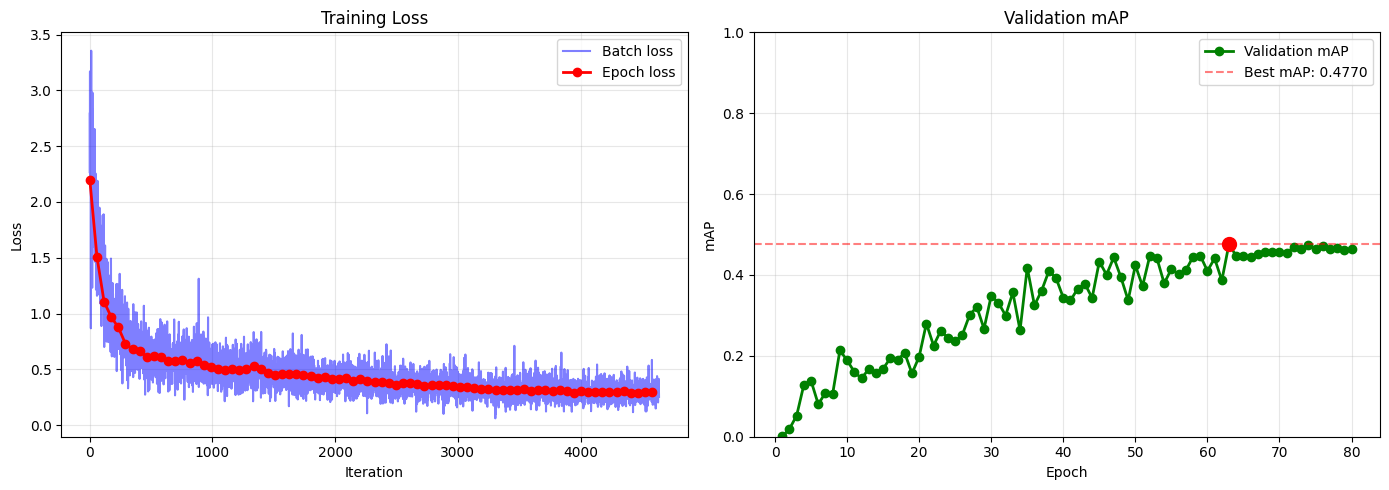

In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

train_dataloader = DataLoader(
    train_dataset, batch_size=config['training']['batch_size'],
    shuffle=True, collate_fn=collate_fn,
)
val_dataloader = DataLoader(
    val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn,
)
test_dataloader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn,
)

model = Detector(**config['model']).to(device)

backbone_params = list(model.backbone.parameters())
head_neck_params = list(model.neck.parameters()) + list(model.head.parameters())
optimizer = optim.AdamW(
    [
        {'params': backbone_params, 'lr': config['training']['lr_backbone']},
        {'params': head_neck_params, 'lr': config['training']['lr_head']},
    ],
    weight_decay=config['training']['weight_decay'],
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['training']['num_epochs'],
    eta_min=1e-6,
)

compute_loss = ComputeLoss(bbox_loss=diou_loss, **config['loss'])

runner = Runner(
    model=model,
    compute_loss=compute_loss,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    assign_target_method=TAL_assigner,
    device=device,
    scheduler=scheduler,
    val_dataloader=val_dataloader,
    save_best=True,
    warmup_epochs=config['training']['warmup_epochs'],
    grad_clip=config['training']['grad_clip'],
    assign_target_kwargs=config['assigner'],
    **config['runner'],
)


runner.train(num_epochs=config['training']['num_epochs'], verbose=True)
runner.plot_metrics()

In [34]:
runner.load_best_model()
final_map = runner.evaluate(test_dataloader)
print(f'Final test mAP: {final_map:.4f}')

Loaded best model from best_model.pth


  0%|          | 0/136 [00:00<?, ?it/s]

Final test mAP: 0.4278


In [35]:
# визуализация итогов
def visualize_predictions(model, dataloader, device, num_images=4, score_threshold=0.3):
    model.eval()

    images, targets = next(iter(dataloader))
    actual_num = min(num_images, images.shape[0])
    images = images[:actual_num].float().to(device)
    targets = targets[:actual_num]

    with torch.no_grad():
        outputs = model(images)
        predictions = filter_predictions(
            outputs,
            score_threshold=score_threshold,
            nms_threshold=0.5,
            max_boxes_per_cls=50,
            return_type='torch',
        )

    fig, axes = plt.subplots(1, actual_num, figsize=(5 * actual_num, 5))
    if actual_num == 1:
        axes = [axes]

    for i in range(actual_num):
        # делаем обратную нормализацию
        img = images[i].cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)
        
        if img.max() - img.min() < 0.3:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        ax = axes[i]
        ax.imshow(img)

        # подсчитываем количество GT объектов
        num_gt = 0

        if i < len(targets) and "boxes" in targets[i]:
            gt_boxes = targets[i]["boxes"]
            gt_labels = targets[i].get("labels", [0] * len(gt_boxes))
            num_gt = len(gt_boxes)  # считаем GT объекты
            
            for box, label in zip(gt_boxes, gt_labels):
                x1, y1, x2, y2 = box.cpu().numpy()
                class_id = int(label) + 1  
                color = class_to_color.get(class_id, (128, 128, 128))
                color_norm = tuple(c / 255 for c in color)
                class_name = class_to_name.get(class_id, f'C{class_id}')
                
                rect = plt.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, edgecolor=color_norm, linewidth=2,
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, f"GT: {class_name}", 
                       color=color_norm, fontsize=8,
                       bbox=dict(facecolor='white', alpha=0.7))

        # подсчитываем количество предсказаний
        num_pred = len(predictions[i]['boxes'])
        
        # предсказания
        for box, label, score in zip(
            predictions[i]["boxes"],
            predictions[i]["labels"],
            predictions[i]["scores"],
        ):
            if score > score_threshold:
                x1, y1, x2, y2 = box.cpu().numpy()
                class_id = int(label) + 1
                color = class_to_color.get(class_id, (128, 128, 128))
                color_norm = tuple(c / 255 for c in color)
                class_name = class_to_name.get(class_id, f"C{class_id}")
                
                rect = plt.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    fill=False, edgecolor=color_norm, linewidth=2,
                )
                ax.add_patch(rect)
                ax.text(x1, y2 + 5, f'{class_name}: {score:.2f}',
                       color=color_norm, fontsize=8,
                       bbox=dict(facecolor='white', alpha=0.7))

        ax.set_title(f'Image {i+1} | Found: {num_pred} / {num_gt} objects', fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

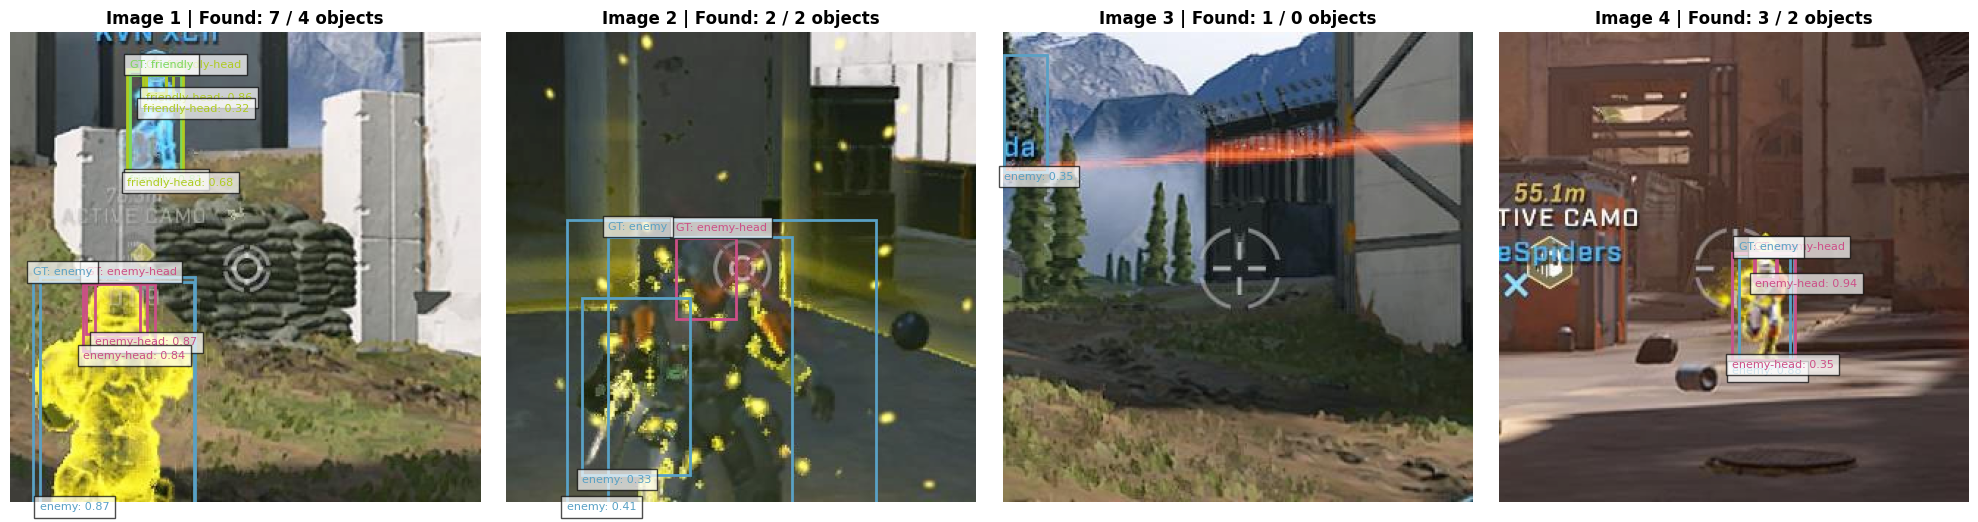

In [36]:
vis_dataloader = DataLoader(
    test_dataset, 
    batch_size=4, 
    shuffle=False, 
    collate_fn=collate_fn
)

visualize_predictions(
    model=model,
    dataloader=vis_dataloader,
    device=device,
    num_images=6,
    score_threshold=0.3,  # показываем предсказания с уверенностью >30%
)

**Результаты:** <br>
Часть кода взял из семинара, как было сказано в самом начале <br>
Изначально mAP был вообще низкого уровня, поэтому постепенно экспериментировал с предложенными улучшениями для поднятия метрики. Хорошего результата получилось добиться используя: <br>
1. Использовал формат xyxy
2. использовал tal_assigner
3. добавил аугментаций
4. использовал cspblock в шее
5. учел дисбаланс классов

После 60 эпохи модель вышла на плато и держалась в районе 0.45, поэтому увеличивать количество эпох не стал, в некоторых статьях говорится что результат еще лучше на 100+ эпохах. <br>
**Final test mAP: 0.4278**


*Ответы на вопросы:*<br>
**Вопрос 1: Какой метод label assignment'a помогает лучше обучаться модели? Почему?**<br>
TAL_assigner - это наиболее эффективный метод присвоения якорей к объектам. Он одновременно оценивает *Насколько модель уверена в классе (классификация)* и *Насколько точно предсказаны координаты (регрессия)*<br>
**Вопрос 2: Какое из сделанных вами улучшений внесло наибольший вклад в качество модели? Как вы думаете, почему это произошло?**<br>
В виду нашего дисбаланса увеличение веса объектности `weight_obj` и `pos_weight` оказалось самым важным регением. Без балансировки модель часто предсказывала пусто из-за пустых якорей. <br>
**Вопрос 3: Какое из сделанных вами улучшений вообще не изменило метрику? Как вы думаете, почему это произошло?** <br>
Скорее всего сюда можно отнести часть аугментаций, там не всегда выставлена высокая вероятность, плюс изначально изображения высокого качества. Часть аугментаций перекрывает друг друга, важно соблюдать очередность и необходимость каждого преобразования.